#### Ryanair Price Analysis: 
#### Scraping and Analyzing Ryanair Flight Prices
#### 2nd Part 
Merlin Mirley Moreno Palacios 
Date: 04/2026

#### 5. Loading the dataset

After completing the scraping process, the flight data is stored in a CSV file. The next step is to load this dataset into Python and inspect its structure before performing any cleaning or analysis.

This step is essential to verify that the data has been correctly collected and to identify potential issues such as missing values, incorrect data types, or inconsistencies.

In [210]:
import pandas as pd

df = pd.read_csv("flight_data.csv") # Replace "flight_data.csv" with the actual path to your CSV file
# check the first few rows of the dataframe to see the structure of the data
df.head(2)

,Scrape Date,Flight Number,Origin City,Origin Airport,Destination City,Destination Airport,Departure Date,Departure Time,Arrival Time,Price
0,"2026-02-18,FR 2663,Fráncfort Hahn,HHN,Alicante...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"*""",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


When loading the dataset, the data was not correctly split into columns. Instead, each row was interpreted as a single text string.

This problem is caused by formatting issues in the CSV file, particularly the use of quotation marks and commas within the data.

#### 5. Repairing the raw dataset structure

When the raw file was loaded, it became clear that the observations were not being parsed as a structured table. Instead, many rows were stored as quoted text strings, and the price variable contained embedded commas that disrupted the column separation.

To solve this issue, I read the file line by line, preserved the header, removed malformed quotation marks, filtered out corrupted rows, and manually reconstructed the price field. This made it possible to rebuild the dataset into a valid tabular format before proceeding with the cleaning and analysis stages.

In [211]:
import pandas as pd

# Read the raw file line by line
with open("flight_data.csv", "r", encoding="utf-8") as f:
    lines = f.readlines()

# Extract the header from the first line
header = lines[0].strip().split(",")

# Initialize a list to store cleaned rows
rows = []

# Process each data row
for line in lines[1:]:
    line = line.strip()
    
    # Skip empty or malformed lines
    if not line or "*""" in line:
        continue
    
    # Remove outer quotation marks if present
    if line.startswith('"') and line.endswith('"'):
        line = line[1:-1]
    
    # Remove duplicated quotation marks
    line = line.replace('""', '')
    
    # Split the row by commas
    parts = line.split(",")
    
    # Skip rows that do not contain enough elements
    if len(parts) < 9:
        continue
    
    # Keep the first 9 fixed columns
    fixed = parts[:9]
    
    # Reconstruct the price field, which may contain a decimal comma
    price = ",".join(parts[9:])
    
    # Rebuild the full row
    row = fixed + [price]
    
    # Append the cleaned row to the list
    rows.append(row)

# Create the DataFrame from the cleaned rows
df = pd.DataFrame(rows, columns=header)

# Remove unnamed or invalid columns if any were created
df = df.loc[:, df.columns.notna()]

# Display the first rows of the repaired dataset
df.head(2)


,Scrape Date,Flight Number,Origin City,Origin Airport,Destination City,Destination Airport,Departure Date,Departure Time,Arrival Time,Price
0,2026-02-18,FR 2663,Fráncfort Hahn,HHN,Alicante,ALC,2026-02-20,06:20,09:00,"156,99 €"
1,2026-02-18,FR 2663,Fráncfort Hahn,HHN,Alicante,ALC,2026-02-21,17:45,20:25,"60,99 €"


In [212]:
df.head(2000)

,Scrape Date,Flight Number,Origin City,Origin Airport,Destination City,Destination Airport,Departure Date,Departure Time,Arrival Time,Price
0,2026-02-18,FR 2663,Fráncfort Hahn,HHN,Alicante,ALC,2026-02-20,06:20,09:00,"156,99 €"
1,2026-02-18,FR 2663,Fráncfort Hahn,HHN,Alicante,ALC,2026-02-21,17:45,20:25,"60,99 €"
2,2026-02-18,FR 2663,Fráncfort Hahn,HHN,Alicante,ALC,2026-02-22,13:15,15:55,"110,99 €"
3,2026-02-18,FR 2663,Fráncfort Hahn,HHN,Alicante,ALC,2026-02-23,19:50,22:30,"40,99 €"
4,2026-02-18,FR 2663,Fráncfort Hahn,HHN,Alicante,ALC,2026-02-25,15:10,17:50,"63,99 €"
...,...,...,...,...,...,...,...,...,...,...
1995,2026-02-19 19:15:08,FR 2814,Londres Stansted,STN,Colonia,CGN,2026-04-16,17:10,19:30,"24,99 £"
1996,2026-02-19 19:15:08,FR 2352,Londres Stansted,STN,Colonia,CGN,2026-04-17,09:00,11:20,"54,99 £"
1997,2026-02-19 19:15:08,FR 2814,Londres Stansted,STN,Colonia,CGN,2026-04-17,14:30,16:50,"56,59 £"
1998,2026-02-19 19:15:08,FR 2816,Londres Stansted,STN,Colonia,CGN,2026-04-17,17:00,19:20,"17,00 £"


In [213]:
df.shape

(9258, 10)

In [214]:
df.columns

Index(['Scrape Date', 'Flight Number', 'Origin City', 'Origin Airport',
       'Destination City', 'Destination Airport', 'Departure Date',
       'Departure Time', 'Arrival Time', 'Price'],
      dtype='str')

In [215]:
df.dtypes

Scrape Date            str
Flight Number          str
Origin City            str
Origin Airport         str
Destination City       str
Destination Airport    str
Departure Date         str
Departure Time         str
Arrival Time           str
Price                  str
dtype: object

## 6. Dataset overview

The repaired dataset consists of 9,258 observations and 10 variables, corresponding to a shape of `(9258, 10)`.

The variables included are: `Scrape Date`, `Flight Number`, `Origin City`, `Origin Airport`, `Destination City`, `Destination Airport`, `Departure Date`, `Departure Time`, `Arrival Time`, and `Price`.

A preliminary inspection shows that all variables are currently stored as strings. As a result, the dataset requires additional type conversion and cleaning before it can be used for meaningful analysis.

In [216]:
df[(df["Price"] == "sold out")]

,Scrape Date,Flight Number,Origin City,Origin Airport,Destination City,Destination Airport,Departure Date,Departure Time,Arrival Time,Price
1822,2026-02-19 19:15:08,FR 2813,Colonia,CGN,Londres Stansted,STN,2026-03-29,11:45,12:05,sold out
3337,2026-02-20 15:41:59,FR 2813,Colonia,CGN,Londres Stansted,STN,2026-03-29,11:45,12:05,sold out
4357,2026-02-21 09:11:19,FR 2813,Colonia,CGN,Londres Stansted,STN,2026-03-29,11:45,12:05,sold out
5975,2026-02-22 10:59:18,FR 2813,Colonia,CGN,Londres Stansted,STN,2026-03-29,11:45,12:05,sold out
6443,2026-02-23 10:16:20,FR 2813,Colonia,CGN,Londres Stansted,STN,2026-03-29,11:45,12:05,sold out
8602,2026-02-24 08:46:40,FR 2813,Colonia,CGN,Londres Stansted,STN,2026-03-29,11:45,12:05,sold out


#### Handling sold-out observations

Some flights in the dataset are marked as "sold out", meaning that no price is available for those observations.

Since these entries do not contain valid price information, they cannot be used in numerical analysis. Therefore, I remove these observations from the dataset to ensure that all remaining data points correspond to actual prices.

In [217]:
# Replace "sold out" with missing values
df["Price"] = df["Price"].replace("sold out", pd.NA)

# Replace empty strings and whitespace with missing values
df["Price"] = df["Price"].replace(r"^\s*$", pd.NA, regex=True)

# Drop rows with missing prices
df = df.dropna(subset=["Price"])

# Reset index after dropping rows
df = df.reset_index(drop=True)

# Check new shape
df.shape

(9114, 10)

In [218]:
df["Price"].isna().sum()

np.int64(0)

In [219]:
# Create a copy of the original price column
df["Price_raw"] = df["Price"]

# Identify currency
df["currency"] = df["Price_raw"].str.extract(r"(€|£|MAD)")

# Clean numeric part of the price
df["Price_clean"] = (
    df["Price_raw"]
    .str.replace("€", "", regex=False)
    .str.replace("£", "", regex=False)
    .str.replace("MAD", "", regex=False)
       # Remove thousand separators (dot)
    .str.replace(".", "", regex=False)
    
    # Replace decimal comma with dot
    .str.replace(",", ".", regex=False)
    
    # Remove spaces
    .str.strip()
)

# Convert to numeric
df["Price_clean"] = pd.to_numeric(df["Price_clean"], errors="coerce")

# Convert all prices to euros
df["Price_eur"] = df["Price_clean"]

# Apply conversion rates
df.loc[df["currency"] == "£", "Price_eur"] = df["Price_clean"] * 1.15
df.loc[df["currency"] == "MAD", "Price_eur"] = df["Price_clean"] * 0.092

# Final check
df[["Price_raw", "currency", "Price_clean", "Price_eur"]].head()

,Price_raw,currency,Price_clean,Price_eur
0,"156,99 €",€,156.99,156.99
1,"60,99 €",€,60.99,60.99
2,"110,99 €",€,110.99,110.99
3,"40,99 €",€,40.99,40.99
4,"63,99 €",€,63.99,63.99


In [220]:
df["currency"].value_counts()

currency
€      7944
£      1038
MAD     132
Name: count, dtype: int64

In [221]:
df["Price_eur"].describe()

count    9114.000000
mean       69.197874
std        43.491926
min        14.990000
25%        34.390000
50%        60.900000
75%        93.860000
max       336.478500
Name: Price_eur, dtype: float64

In [222]:
df.head(2000)

,Scrape Date,Flight Number,Origin City,Origin Airport,Destination City,Destination Airport,Departure Date,Departure Time,Arrival Time,Price,Price_raw,currency,Price_clean,Price_eur
0,2026-02-18,FR 2663,Fráncfort Hahn,HHN,Alicante,ALC,2026-02-20,06:20,09:00,"156,99 €","156,99 €",€,156.99,156.9900
1,2026-02-18,FR 2663,Fráncfort Hahn,HHN,Alicante,ALC,2026-02-21,17:45,20:25,"60,99 €","60,99 €",€,60.99,60.9900
2,2026-02-18,FR 2663,Fráncfort Hahn,HHN,Alicante,ALC,2026-02-22,13:15,15:55,"110,99 €","110,99 €",€,110.99,110.9900
3,2026-02-18,FR 2663,Fráncfort Hahn,HHN,Alicante,ALC,2026-02-23,19:50,22:30,"40,99 €","40,99 €",€,40.99,40.9900
4,2026-02-18,FR 2663,Fráncfort Hahn,HHN,Alicante,ALC,2026-02-25,15:10,17:50,"63,99 €","63,99 €",€,63.99,63.9900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,2026-02-19 19:15:08,FR 2352,Londres Stansted,STN,Colonia,CGN,2026-04-17,09:00,11:20,"54,99 £","54,99 £",£,54.99,63.2385
1996,2026-02-19 19:15:08,FR 2814,Londres Stansted,STN,Colonia,CGN,2026-04-17,14:30,16:50,"56,59 £","56,59 £",£,56.59,65.0785
1997,2026-02-19 19:15:08,FR 2816,Londres Stansted,STN,Colonia,CGN,2026-04-17,17:00,19:20,"17,00 £","17,00 £",£,17.00,19.5500
1998,2026-02-19 19:15:08,FR 2814,Londres Stansted,STN,Colonia,CGN,2026-04-18,09:00,11:20,"25,99 £","25,99 £",£,25.99,29.8885


In [223]:
df[(df["currency"]=="£")]

,Scrape Date,Flight Number,Origin City,Origin Airport,Destination City,Destination Airport,Departure Date,Departure Time,Arrival Time,Price,Price_raw,currency,Price_clean,Price_eur
253,2026-02-18 16:18:28,FR 6199,Londres Stansted,STN,Fráncfort Hahn,HHN,2026-03-20,06:15,08:40,"15,70 £","15,70 £",£,15.70,18.0550
254,2026-02-18 16:18:28,FR 1749,Londres Stansted,STN,Fráncfort Hahn,HHN,2026-03-20,17:05,19:30,"14,99 £","14,99 £",£,14.99,17.2385
255,2026-02-18 16:18:28,FR 1749,Londres Stansted,STN,Fráncfort Hahn,HHN,2026-03-21,08:10,10:35,"14,99 £","14,99 £",£,14.99,17.2385
256,2026-02-18 16:18:28,FR 6199,Londres Stansted,STN,Fráncfort Hahn,HHN,2026-03-21,13:40,16:05,"14,99 £","14,99 £",£,14.99,17.2385
257,2026-02-18 16:18:28,FR 6207,Londres Stansted,STN,Fráncfort Hahn,HHN,2026-03-21,20:25,22:50,"17,99 £","17,99 £",£,17.99,20.6885
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8857,2026-02-24 08:46:40,FR 2814,Londres Stansted,STN,Colonia,CGN,2026-04-17,14:30,16:50,"53,84 £","53,84 £",£,53.84,61.9160
8858,2026-02-24 08:46:40,FR 2816,Londres Stansted,STN,Colonia,CGN,2026-04-17,17:00,19:20,"20,99 £","20,99 £",£,20.99,24.1385
8859,2026-02-24 08:46:40,FR 2814,Londres Stansted,STN,Colonia,CGN,2026-04-18,09:00,11:20,"22,99 £","22,99 £",£,22.99,26.4385
8860,2026-02-24 08:46:40,RK 2816,Londres Stansted,STN,Colonia,CGN,2026-04-18,15:25,17:45,"14,99 £","14,99 £",£,14.99,17.2385


In [224]:
df["Price_eur"].isna().sum()

np.int64(0)

In [226]:
df.shape

(9114, 14)

## 7. Type conversion and data cleaning

After repairing the raw dataset structure, the next step is to convert the variables into appropriate data types.

At this stage, all columns are still stored as strings, which limits the possibility of performing numerical operations, date manipulations, or statistical analysis. Therefore, I convert the date variables into datetime format and clean the price variable so that it can be interpreted as numeric.

This step is essential for transforming the scraped dataset into an analysis-ready table.

## 10. Final data type conversion

After cleaning the raw price variable and converting all values into euros, the dataset is now ready for final type conversion.

At this stage, I convert the date variables into datetime format and ensure that the standardized price variable (`Price_eur`) is stored as a numeric value. This step prepares the dataset for analysis and modeling.

##############ver desde aqui 

In [227]:
import re

# Function to extract clean date (YYYY-MM-DD)
def extract_date(value):
    if pd.isna(value):
        return pd.NA
    
    # Convert to string just in case
    value = str(value)
    
    # Search for pattern YYYY-MM-DD
    match = re.search(r"\d{4}-\d{2}-\d{2}", value)
    
    if match:
        return match.group(0)
    else:
        return pd.NA

# Apply function to both date columns
df["Scrape Date"] = df["Scrape Date"].apply(extract_date)
df["Departure Date"] = df["Departure Date"].apply(extract_date)

# Convert to datetime
df["Scrape Date"] = pd.to_datetime(df["Scrape Date"], errors="coerce")
df["Departure Date"] = pd.to_datetime(df["Departure Date"], errors="coerce")

# Check results
df[["Scrape Date", "Departure Date"]].head()

,Scrape Date,Departure Date
0,2026-02-18,2026-02-20
1,2026-02-18,2026-02-21
2,2026-02-18,2026-02-22
3,2026-02-18,2026-02-23
4,2026-02-18,2026-02-25


In [229]:
df["Scrape Date"].isna().sum()


np.int64(0)

In [230]:
df["Departure Date"].isna().sum()

np.int64(0)

In [231]:
df.head(2000)

,Scrape Date,Flight Number,Origin City,Origin Airport,Destination City,Destination Airport,Departure Date,Departure Time,Arrival Time,Price,Price_raw,currency,Price_clean,Price_eur
0,2026-02-18,FR 2663,Fráncfort Hahn,HHN,Alicante,ALC,2026-02-20,06:20,09:00,"156,99 €","156,99 €",€,156.99,156.9900
1,2026-02-18,FR 2663,Fráncfort Hahn,HHN,Alicante,ALC,2026-02-21,17:45,20:25,"60,99 €","60,99 €",€,60.99,60.9900
2,2026-02-18,FR 2663,Fráncfort Hahn,HHN,Alicante,ALC,2026-02-22,13:15,15:55,"110,99 €","110,99 €",€,110.99,110.9900
3,2026-02-18,FR 2663,Fráncfort Hahn,HHN,Alicante,ALC,2026-02-23,19:50,22:30,"40,99 €","40,99 €",€,40.99,40.9900
4,2026-02-18,FR 2663,Fráncfort Hahn,HHN,Alicante,ALC,2026-02-25,15:10,17:50,"63,99 €","63,99 €",€,63.99,63.9900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,2026-02-19,FR 2352,Londres Stansted,STN,Colonia,CGN,2026-04-17,09:00,11:20,"54,99 £","54,99 £",£,54.99,63.2385
1996,2026-02-19,FR 2814,Londres Stansted,STN,Colonia,CGN,2026-04-17,14:30,16:50,"56,59 £","56,59 £",£,56.59,65.0785
1997,2026-02-19,FR 2816,Londres Stansted,STN,Colonia,CGN,2026-04-17,17:00,19:20,"17,00 £","17,00 £",£,17.00,19.5500
1998,2026-02-19,FR 2814,Londres Stansted,STN,Colonia,CGN,2026-04-18,09:00,11:20,"25,99 £","25,99 £",£,25.99,29.8885


In [232]:


# Ensure price in euros is numeric
df["Price_eur"] = pd.to_numeric(df["Price_eur"], errors="coerce")

# Optional: drop any remaining missing prices
df = df.dropna(subset=["Price_eur"])

# Reset index after cleaning
df = df.reset_index(drop=True)

# Display updated data types
df.dtypes

Scrape Date            datetime64[us]
Flight Number                     str
Origin City                       str
Origin Airport                    str
Destination City                  str
Destination Airport               str
Departure Date         datetime64[us]
Departure Time                    str
Arrival Time                      str
Price                             str
Price_raw                         str
currency                          str
Price_clean                   float64
Price_eur                     float64
dtype: object

In [234]:
# Convert time columns to datetime format
df["Departure Time"] = pd.to_datetime(df["Departure Time"], format="%H:%M", errors="coerce")
df["Arrival Time"] = pd.to_datetime(df["Arrival Time"], format="%H:%M", errors="coerce")

# Calculate flight duration
df["flight_duration"] = df["Arrival Time"] - df["Departure Time"]

df[["Departure Time", "Arrival Time", "flight_duration"]].head()

,Departure Time,Arrival Time,flight_duration
0,1900-01-01 06:20:00,1900-01-01 09:00:00,0 days 02:40:00
1,1900-01-01 17:45:00,1900-01-01 20:25:00,0 days 02:40:00
2,1900-01-01 13:15:00,1900-01-01 15:55:00,0 days 02:40:00
3,1900-01-01 19:50:00,1900-01-01 22:30:00,0 days 02:40:00
4,1900-01-01 15:10:00,1900-01-01 17:50:00,0 days 02:40:00


In [235]:
# Fix overnight flights (arrival next day)
df.loc[df["flight_duration"] < pd.Timedelta(0), "flight_duration"] += pd.Timedelta(days=1)

In [236]:
df["flight_duration"].describe()

count                      9114
mean     0 days 02:10:49.907834
std      0 days 00:47:48.177419
min             0 days 00:20:00
25%             0 days 02:05:00
50%             0 days 02:20:00
75%             0 days 02:30:00
max             0 days 05:40:00
Name: flight_duration, dtype: object

In [237]:
df["duration_minutes"] = df["flight_duration"].dt.total_seconds() / 60 # Convert duration to minutes

In [238]:
df.head(2)

,Scrape Date,Flight Number,Origin City,Origin Airport,Destination City,Destination Airport,Departure Date,Departure Time,Arrival Time,Price,Price_raw,currency,Price_clean,Price_eur,flight_duration,duration_minutes
0,2026-02-18,FR 2663,Fráncfort Hahn,HHN,Alicante,ALC,2026-02-20,1900-01-01 06:20:00,1900-01-01 09:00:00,"156,99 €","156,99 €",€,156.99,156.99,0 days 02:40:00,160.0
1,2026-02-18,FR 2663,Fráncfort Hahn,HHN,Alicante,ALC,2026-02-21,1900-01-01 17:45:00,1900-01-01 20:25:00,"60,99 €","60,99 €",€,60.99,60.99,0 days 02:40:00,160.0


In [240]:
# Create days-to-departure variable
df["days_to_departure"] = (df["Departure Date"] - df["Scrape Date"]).dt.days

# Quick check
df[["Scrape Date", "Departure Date", "days_to_departure"]].head(6)

,Scrape Date,Departure Date,days_to_departure
0,2026-02-18,2026-02-20,2
1,2026-02-18,2026-02-21,3
2,2026-02-18,2026-02-22,4
3,2026-02-18,2026-02-23,5
4,2026-02-18,2026-02-25,7
5,2026-02-18,2026-02-19,1


In [241]:
df["days_to_departure"].describe()

count    9114.000000
mean       41.890608
std         8.922013
min         1.000000
25%        35.000000
50%        42.000000
75%        49.000000
max        59.000000
Name: days_to_departure, dtype: float64

In [245]:
df.head(10)

,Scrape Date,Flight Number,Origin City,Origin Airport,Destination City,Destination Airport,Departure Date,Departure Time,Arrival Time,Price,Price_raw,currency,Price_clean,Price_eur,flight_duration,duration_minutes,days_to_departure
0,2026-02-18,FR 2663,Fráncfort Hahn,HHN,Alicante,ALC,2026-02-20,1900-01-01 06:20:00,1900-01-01 09:00:00,"156,99 €","156,99 €",€,156.99,156.99,0 days 02:40:00,160.0,2
1,2026-02-18,FR 2663,Fráncfort Hahn,HHN,Alicante,ALC,2026-02-21,1900-01-01 17:45:00,1900-01-01 20:25:00,"60,99 €","60,99 €",€,60.99,60.99,0 days 02:40:00,160.0,3
2,2026-02-18,FR 2663,Fráncfort Hahn,HHN,Alicante,ALC,2026-02-22,1900-01-01 13:15:00,1900-01-01 15:55:00,"110,99 €","110,99 €",€,110.99,110.99,0 days 02:40:00,160.0,4
3,2026-02-18,FR 2663,Fráncfort Hahn,HHN,Alicante,ALC,2026-02-23,1900-01-01 19:50:00,1900-01-01 22:30:00,"40,99 €","40,99 €",€,40.99,40.99,0 days 02:40:00,160.0,5
4,2026-02-18,FR 2663,Fráncfort Hahn,HHN,Alicante,ALC,2026-02-25,1900-01-01 15:10:00,1900-01-01 17:50:00,"63,99 €","63,99 €",€,63.99,63.99,0 days 02:40:00,160.0,7
5,2026-02-18,FR 1680,Fráncfort Hahn,HHN,Barcelona-El Prat,BCN,2026-02-19,1900-01-01 15:40:00,1900-01-01 17:55:00,"165,99 €","165,99 €",€,165.99,165.99,0 days 02:15:00,135.0,1
6,2026-02-18,FR 1680,Fráncfort Hahn,HHN,Barcelona-El Prat,BCN,2026-02-21,1900-01-01 11:10:00,1900-01-01 13:25:00,"113,34 €","113,34 €",€,113.34,113.34,0 days 02:15:00,135.0,3
7,2026-02-18,FR 1680,Fráncfort Hahn,HHN,Barcelona-El Prat,BCN,2026-02-22,1900-01-01 15:10:00,1900-01-01 17:25:00,"99,99 €","99,99 €",€,99.99,99.99,0 days 02:15:00,135.0,4
8,2026-02-18,FR 1680,Fráncfort Hahn,HHN,Barcelona-El Prat,BCN,2026-02-23,1900-01-01 12:45:00,1900-01-01 15:00:00,"63,99 €","63,99 €",€,63.99,63.99,0 days 02:15:00,135.0,5
9,2026-02-18,FR 9926,Fráncfort Hahn,HHN,Barcelona-El Prat,BCN,2026-02-25,1900-01-01 15:15:00,1900-01-01 17:30:00,"76,99 €","76,99 €",€,76.99,76.99,0 days 02:15:00,135.0,7


In [246]:
df["days_to_departure"].unique()

array([ 2,  3,  4,  5,  7,  1, 30, 31, 32, 33, 35, 37, 38, 39, 40, 43, 44,
       45, 46, 47, 50, 51, 52, 53, 54, 57, 58, 59, 36, 41, 48, 55, 42, 49,
       56, 34, 29, 28, 27, 26, 25, 24])

## 13. Price dynamics over time

To analyze pricing behavior, I examine how ticket prices evolve as the departure date approaches.

I plot the relationship between the price (in euros) and the number of days to departure. This visualization helps identify whether prices increase, decrease, or follow a non-linear pattern as the booking date gets closer to the travel date.

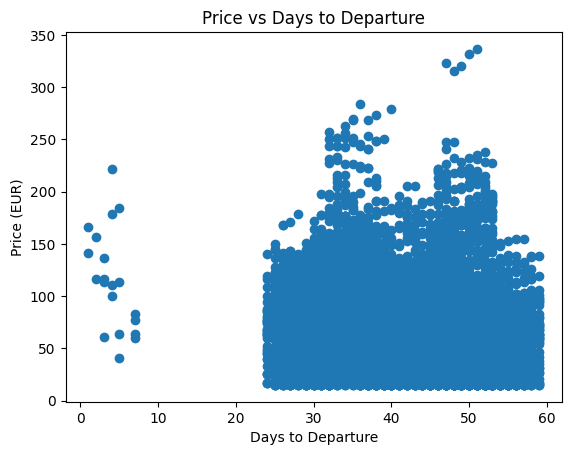

In [258]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(df["days_to_departure"], df["Price_eur"])

plt.xlabel("Days to Departure")
plt.ylabel("Price (EUR)")
plt.title("Price vs Days to Departure")

plt.show()

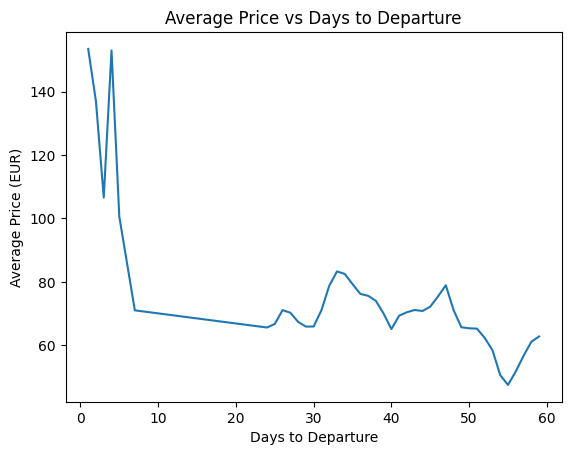

In [260]:
import numpy as np

# Average price by day
avg_price = df.groupby("days_to_departure")["Price_eur"].mean()

plt.figure()

plt.plot(avg_price.index, avg_price.values)

plt.xlabel("Days to Departure")
plt.ylabel("Average Price (EUR)")
plt.title("Average Price vs Days to Departure")

plt.show()

In [261]:
# Create subset for observations with more than 20 days to departure
df_long_horizon = df[df["days_to_departure"] > 20].copy()

# Check shape
df_long_horizon.shape

(9094, 17)

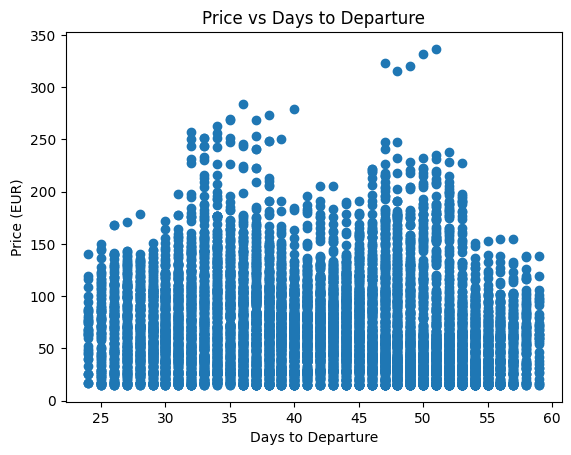

In [262]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(df_long_horizon["days_to_departure"], df_long_horizon["Price_eur"])

plt.xlabel("Days to Departure")
plt.ylabel("Price (EUR)")
plt.title("Price vs Days to Departure")

plt.show()

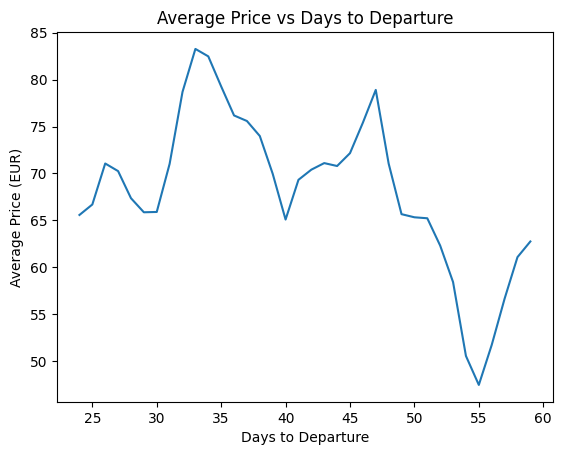

In [263]:
import numpy as np

# Average price by day
avg_price = df_long_horizon.groupby("days_to_departure")["Price_eur"].mean()

plt.figure()

plt.plot(avg_price.index, avg_price.values)

plt.xlabel("Days to Departure")
plt.ylabel("Average Price (EUR)")
plt.title("Average Price vs Days to Departure")

plt.show()

In [264]:
df.head(2)

,Scrape Date,Flight Number,Origin City,Origin Airport,Destination City,Destination Airport,Departure Date,Departure Time,Arrival Time,Price,Price_raw,currency,Price_clean,Price_eur,flight_duration,duration_minutes,days_to_departure
0,2026-02-18,FR 2663,Fráncfort Hahn,HHN,Alicante,ALC,2026-02-20,1900-01-01 06:20:00,1900-01-01 09:00:00,"156,99 €","156,99 €",€,156.99,156.99,0 days 02:40:00,160.0,2
1,2026-02-18,FR 2663,Fráncfort Hahn,HHN,Alicante,ALC,2026-02-21,1900-01-01 17:45:00,1900-01-01 20:25:00,"60,99 €","60,99 €",€,60.99,60.99,0 days 02:40:00,160.0,3


In [267]:
# Create route variable
df["route"] = df["Origin Airport"] + "-" + df["Destination Airport"]

# Check result
df[["Origin Airport", "Destination Airport", "route"]].head(2000)

,Origin Airport,Destination Airport,route
0,HHN,ALC,HHN-ALC
1,HHN,ALC,HHN-ALC
2,HHN,ALC,HHN-ALC
3,HHN,ALC,HHN-ALC
4,HHN,ALC,HHN-ALC
...,...,...,...
1995,STN,CGN,STN-CGN
1996,STN,CGN,STN-CGN
1997,STN,CGN,STN-CGN
1998,STN,CGN,STN-CGN


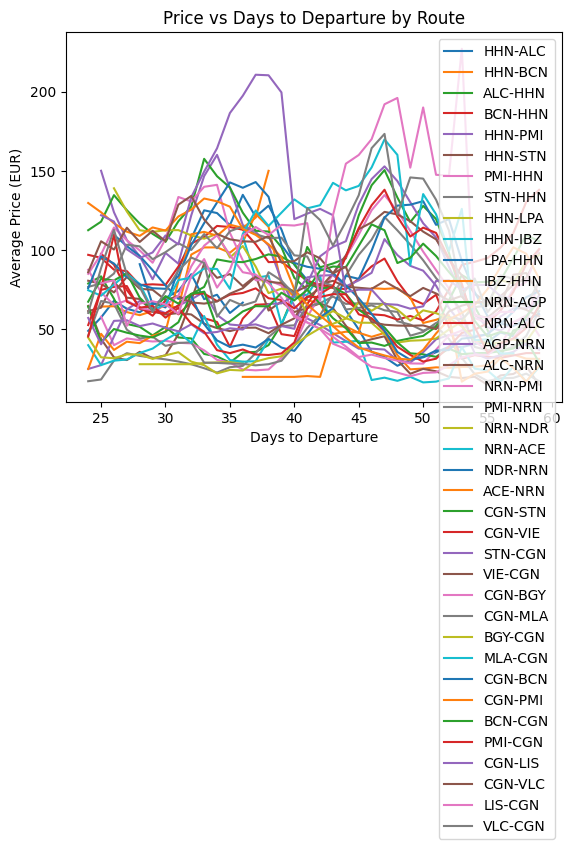

In [ ]:
import matplotlib.pyplot as plt

# Create route variable for the long horizon subset
df_long_horizon["route"] = (
    df_long_horizon["Origin Airport"] + "-" + df_long_horizon["Destination Airport"]
)

# Get unique routes
routes = df_long_horizon["route"].unique()

plt.figure()

# Loop through each route and plot
for route in routes:
    
    df_route = df_long_horizon[df_long_horizon["route"] == route]
    
    avg_price = df_route.groupby("days_to_departure")["Price_eur"].mean()
    
    plt.plot(
        avg_price.index,
        avg_price.values,
        label=route
    )

# Labels and title
plt.xlabel("Days to Departure")
plt.ylabel("Average Price (EUR)")
plt.title("Price vs Days to Departure by Route")

# Legend
plt.legend()

plt.show()

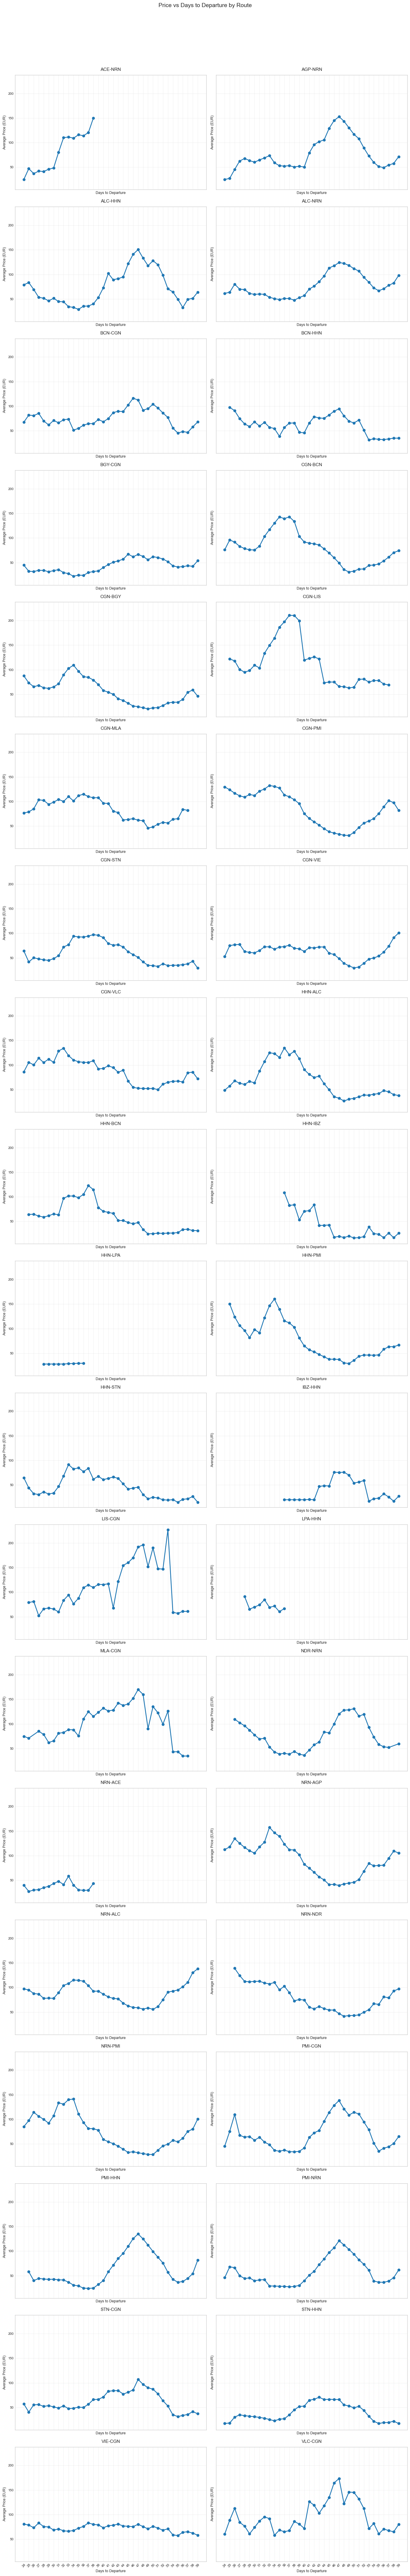

In [274]:
import math
import matplotlib.pyplot as plt

# Subset: keep only observations with more than 20 days to departure
df_long_horizon = df[df["days_to_departure"] > 20].copy()

# Create route variable
df_long_horizon["route"] = (
    df_long_horizon["Origin Airport"].str.strip()
    + "-"
    + df_long_horizon["Destination Airport"].str.strip()
)

# Get unique routes
routes = sorted(df_long_horizon["route"].dropna().unique())

# Define subplot grid
n_routes = len(routes)
n_cols = 2
n_rows = math.ceil(n_routes / n_cols)

# Use a clean style
plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 4.5 * n_rows),
    sharex=True,
    sharey=True
)

# Flatten axes for easier iteration
axes = axes.flatten()

# Get all x-axis values to display
x_ticks = sorted(df_long_horizon["days_to_departure"].dropna().unique())

# Plot one chart per route
for i, route in enumerate(routes):
    ax = axes[i]

    df_route = df_long_horizon[df_long_horizon["route"] == route]

    avg_price = (
        df_route.groupby("days_to_departure")["Price_eur"]
        .mean()
        .sort_index()
    )

    # Line with markers
    ax.plot(
        avg_price.index,
        avg_price.values,
        marker="o",
        linewidth=2
    )

    # Titles and labels
    ax.set_title(route, fontsize=11, pad=10)
    ax.set_xlabel("Days to Departure", fontsize=9)
    ax.set_ylabel("Average Price (EUR)", fontsize=9)

    # Ticks
    ax.set_xticks(x_ticks)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)

    # Make grid lighter
    ax.grid(True, alpha=0.3)

# Remove empty subplots if there are any
for j in range(len(routes), len(axes)):
    fig.delaxes(axes[j])

# Global title
fig.suptitle("Price vs Days to Departure by Route", fontsize=14, y=1.02)

plt.tight_layout()
plt.show()

In [ ]:
df_long_horizon.groupby("route")["Price_eur"].describe() # Get descriptive stats by route for the long horizon subset

,count,mean,std,min,25%,50%,75%,max
route,,,,,,,,
ACE-NRN,28.0,79.350714,40.889641,24.99000,45.96750,75.49000,105.74000,149.9900
AGP-NRN,335.0,81.639134,49.512024,24.99000,41.61000,65.30000,114.91000,231.3000
ALC-HHN,132.0,75.150227,44.366711,21.99000,38.74000,58.99000,104.74000,187.9900
ALC-NRN,294.0,78.404048,40.918919,21.99000,47.99000,70.99000,94.49000,190.6800
BCN-CGN,204.0,77.138137,40.140419,25.49000,42.99000,70.99000,98.99000,225.9900
BCN-HHN,118.0,62.000424,30.495949,16.99000,32.99000,55.58500,87.99000,127.5900
BGY-CGN,230.0,43.978913,22.298230,14.99000,25.71750,43.74500,53.69000,115.3900
CGN-BCN,253.0,79.950711,51.638353,20.00000,39.30000,74.09000,100.99000,283.7600
CGN-BGY,266.0,53.979135,34.613900,14.99000,21.33000,46.09000,73.15000,146.7400


<Figure size 1000x600 with 0 Axes>

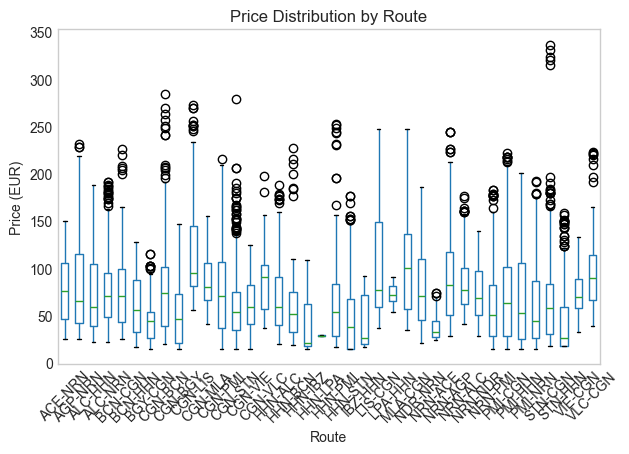

In [280]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

plt.figure(figsize=(10, 6))

# Boxplot
df_long_horizon.boxplot(
    column="Price_eur",
    by="route",
    grid=False
)

# Titles and labels
plt.title("Price Distribution by Route")
plt.suptitle("")  # removes default pandas title
plt.xlabel("Route")
plt.ylabel("Price (EUR)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

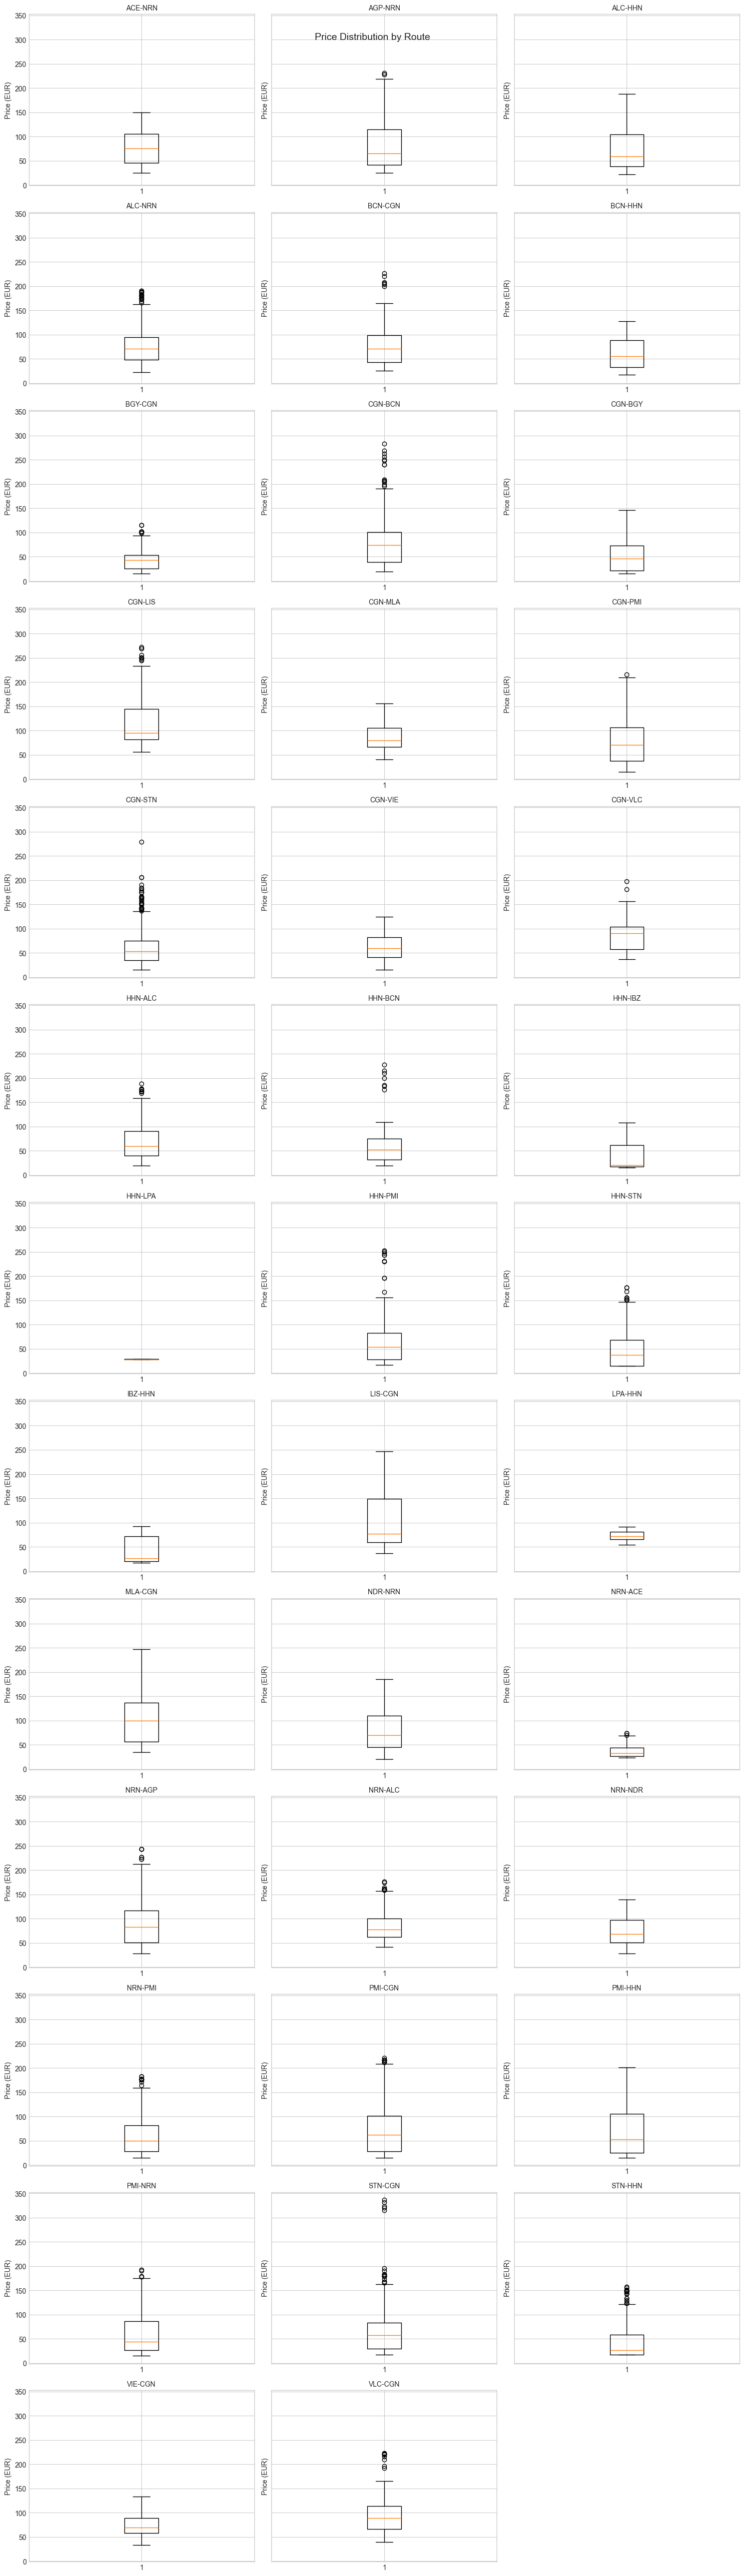

In [281]:
import math
import matplotlib.pyplot as plt

# Ensure route exists
df_long_horizon["route"] = (
    df_long_horizon["Origin Airport"].str.strip()
    + "-"
    + df_long_horizon["Destination Airport"].str.strip()
)

# Unique routes
routes = sorted(df_long_horizon["route"].dropna().unique())

# Grid: 3 per row (como querías antes)
n_cols = 3
n_rows = math.ceil(len(routes) / n_cols)

# Style
plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(15, 4 * n_rows),
    sharey=True
)

axes = axes.flatten()

# Plot each route
for i, route in enumerate(routes):
    ax = axes[i]
    
    data = df_long_horizon[df_long_horizon["route"] == route]["Price_eur"]
    
    ax.boxplot(data, vert=True)
    
    ax.set_title(route, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("Price (EUR)")

# Remove empty plots
for j in range(len(routes), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Price Distribution by Route", fontsize=14)
plt.tight_layout()
plt.show()

In [277]:
import matplotlib.pyplot as plt

# Calculate price volatility by route
price_volatility = (
    df_long_horizon.groupby("route")["Price_eur"]
    .std()
    .reset_index()
)

# Rename column for clarity
price_volatility = price_volatility.rename(columns={"Price_eur": "price_std"})

# Sort routes by volatility
price_volatility = price_volatility.sort_values("price_std", ascending=False)

price_volatility.head(10)

,route,price_std
9,CGN-LIS,61.856263
22,LIS-CGN,60.133582
7,CGN-BCN,51.638353
24,MLA-CGN,50.966181
31,PMI-CGN,50.939194
32,PMI-HHN,49.583334
1,AGP-NRN,49.512024
27,NRN-AGP,45.602055
19,HHN-PMI,45.161167
37,VLC-CGN,44.536328


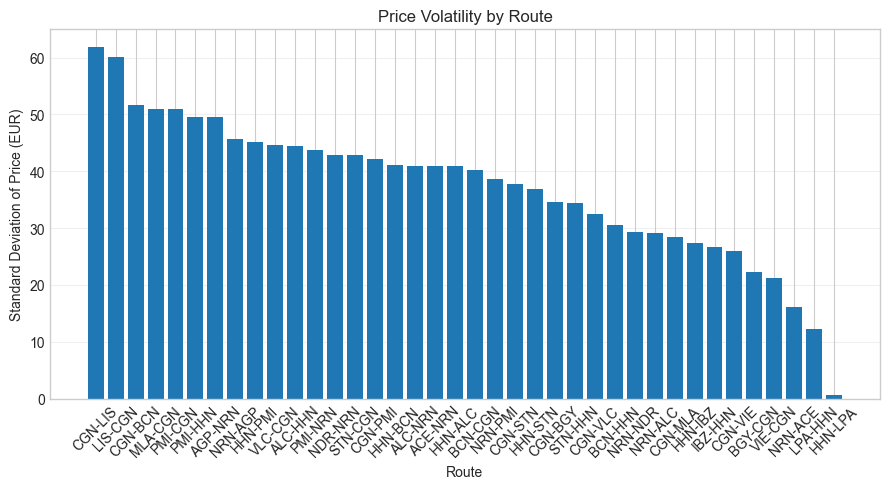

In [278]:
plt.style.use("seaborn-v0_8-whitegrid")

plt.figure(figsize=(9, 5))

plt.bar(price_volatility["route"], price_volatility["price_std"])

plt.xlabel("Route", fontsize=10)
plt.ylabel("Standard Deviation of Price (EUR)", fontsize=10)
plt.title("Price Volatility by Route", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

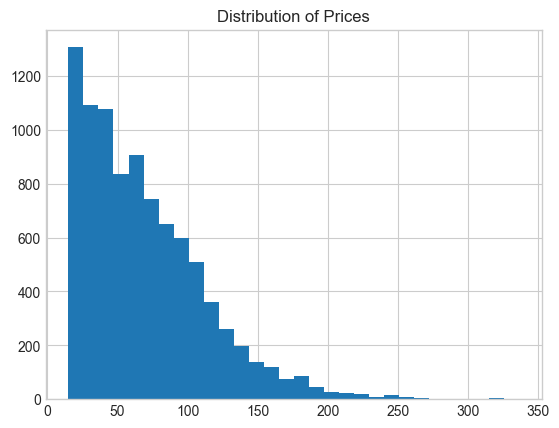

In [276]:
plt.hist(df["Price_eur"], bins=30)
plt.title("Distribution of Prices")
plt.show()